## Q11 — What is the average duration of matches?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load
IN_DIR = "cleaned_data"

event = pd.read_parquet(f'{IN_DIR}/event.parquet')
time_df = pd.read_parquet(f'{IN_DIR}/time.parquet')
hts = pd.read_parquet(f'{IN_DIR}/home_team_score.parquet')
ats = pd.read_parquet(f'{IN_DIR}/away_team_score.parquet')

In [3]:
# Population: matches event confirms actually finished (same reasoning as
# Q5 -- "average duration of A MATCH" should be scoped to matches that
# really happened and concluded), restricted to duration_reliable rows
# (excludes individually-corrupted or known-incomplete time data).
time_df_ok = time_df[time_df['duration_minutes'].between(15, 300)].copy()
m = time_df_ok.merge(event[['match_id', 'match_completed']], on='match_id', how='left')
base = m[(m['duration_reliable']) & (m['match_completed'] == True)].copy()
 
n_reliable_not_completed = int((m['duration_reliable'] & (m['match_completed'] == False)).sum())
print(f"Note: {n_reliable_not_completed} matches have fully reliable time data but no confirmed "
      f"winner in event -- excluded here for the same reason as Q5 (not a confirmed completed match).\n")

Note: 4 matches have fully reliable time data but no confirmed winner in event -- excluded here for the same reason as Q5 (not a confirmed completed match).



In [4]:
# duration_reliable alone doesn't catch every problem (same finding as Q4):
# a match can have every individual period under the 4h cap yet still be
# physically impossible once checked against how many games were actually
# played. Apply the identical games-vs-duration pace cross-check used in Q4.

set_cols = ['period_1', 'period_2', 'period_3']
games = (hts[['match_id'] + set_cols]
         .merge(ats[['match_id'] + set_cols], on='match_id', suffixes=('_h', '_a')))
games['total_games'] = games[[c for c in games.columns if c.startswith('period')]].sum(axis=1)
 
base = base.merge(games[['match_id', 'total_games']], on='match_id', how='left')
base = base[base['total_games'] > 0]
base['sec_per_game'] = base['duration_seconds'] / base['total_games']
 
clean_mean = base['duration_seconds'].mean()
 


In [5]:
print(f"CLEAN mean:          {base['duration_seconds'].mean()/60:.1f} min  "
      f"({base['duration_seconds'].mean():.0f}s)")
print(f"CLEAN median:        {base['duration_seconds'].median()/60:.1f} min")
print(f"CLEAN std dev:       {base['duration_seconds'].std()/60:.1f} min")
print(f"Sample size (n):     {len(base)}")

CLEAN mean:          103.6 min  (6214s)
CLEAN median:        96.8 min
CLEAN std dev:       35.2 min
Sample size (n):     10075


In [6]:
# duration by number of sets (naturally correlated)
sets_played = hts[['match_id']].copy()
sets_played['sets_played'] = hts[set_cols].notna().sum(axis=1)
base = base.merge(sets_played, on='match_id', how='left')
print("\nMean duration by sets played:")
print((base.groupby('sets_played')['duration_seconds'].agg(['mean', 'median', 'count']) / [60, 60, 1])
      .round(1).rename(columns={'mean': 'mean_min', 'median': 'median_min'}))


Mean duration by sets played:
             mean_min  median_min   count
sets_played                              
1                77.1        77.1     1.0
2                87.8        85.2  7005.0
3               139.6       137.2  3069.0


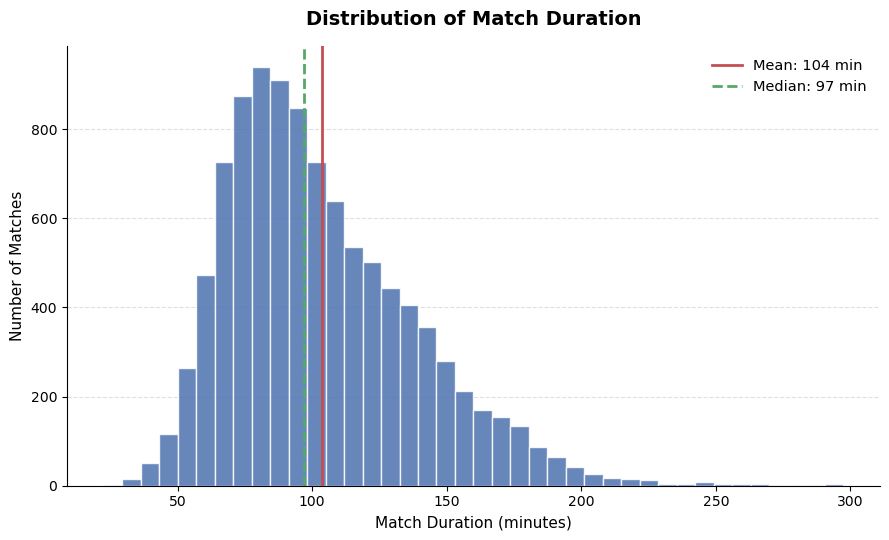

In [7]:
# Visualization
fig, ax = plt.subplots(figsize=(9, 5.5))
minutes = base['duration_seconds'] / 60
ax.hist(minutes, bins=40, color='#4C72B0', edgecolor='white', alpha=0.85)
 
mean_min = minutes.mean()
median_min = minutes.median()
ax.axvline(mean_min, color='#C44E52', linestyle='-', linewidth=2, label=f'Mean: {mean_min:.0f} min')
ax.axvline(median_min, color='#55A868', linestyle='--', linewidth=2, label=f'Median: {median_min:.0f} min')
 
ax.set_xlabel('Match Duration (minutes)', fontsize=11)
ax.set_ylabel('Number of Matches', fontsize=11)
ax.set_title('Distribution of Match Duration', fontsize=14, fontweight='bold', pad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=10.5)
plt.tight_layout()
plt.savefig('charts\q11_duration_distribution.png', dpi=200, bbox_inches='tight')

Observation: Same filters as Q4: 15–300 minutes, duration_reliable, completed matches, games cross-check. Mean 103.6 min, median 96.8, sd 35.2 (n=10,075). By sets: ~87.8 min (2 sets) vs ~139.6 min (3 sets).

Interpretation: Mean above median shows right skew. The ~52-minute gap between 2- and 3-set matches matches the cost of one extra set.

Limitation: Describes the filtered population only; retirements and dropped duration rows are outside scope.